
# Lab1_4: PDE_capacitor

In [8]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [5]:
#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'
filename5 = 'Laplace_df_capacitor.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Potential and Electric field from a capacitor

####Lab1_4_PDE_capacitor:

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

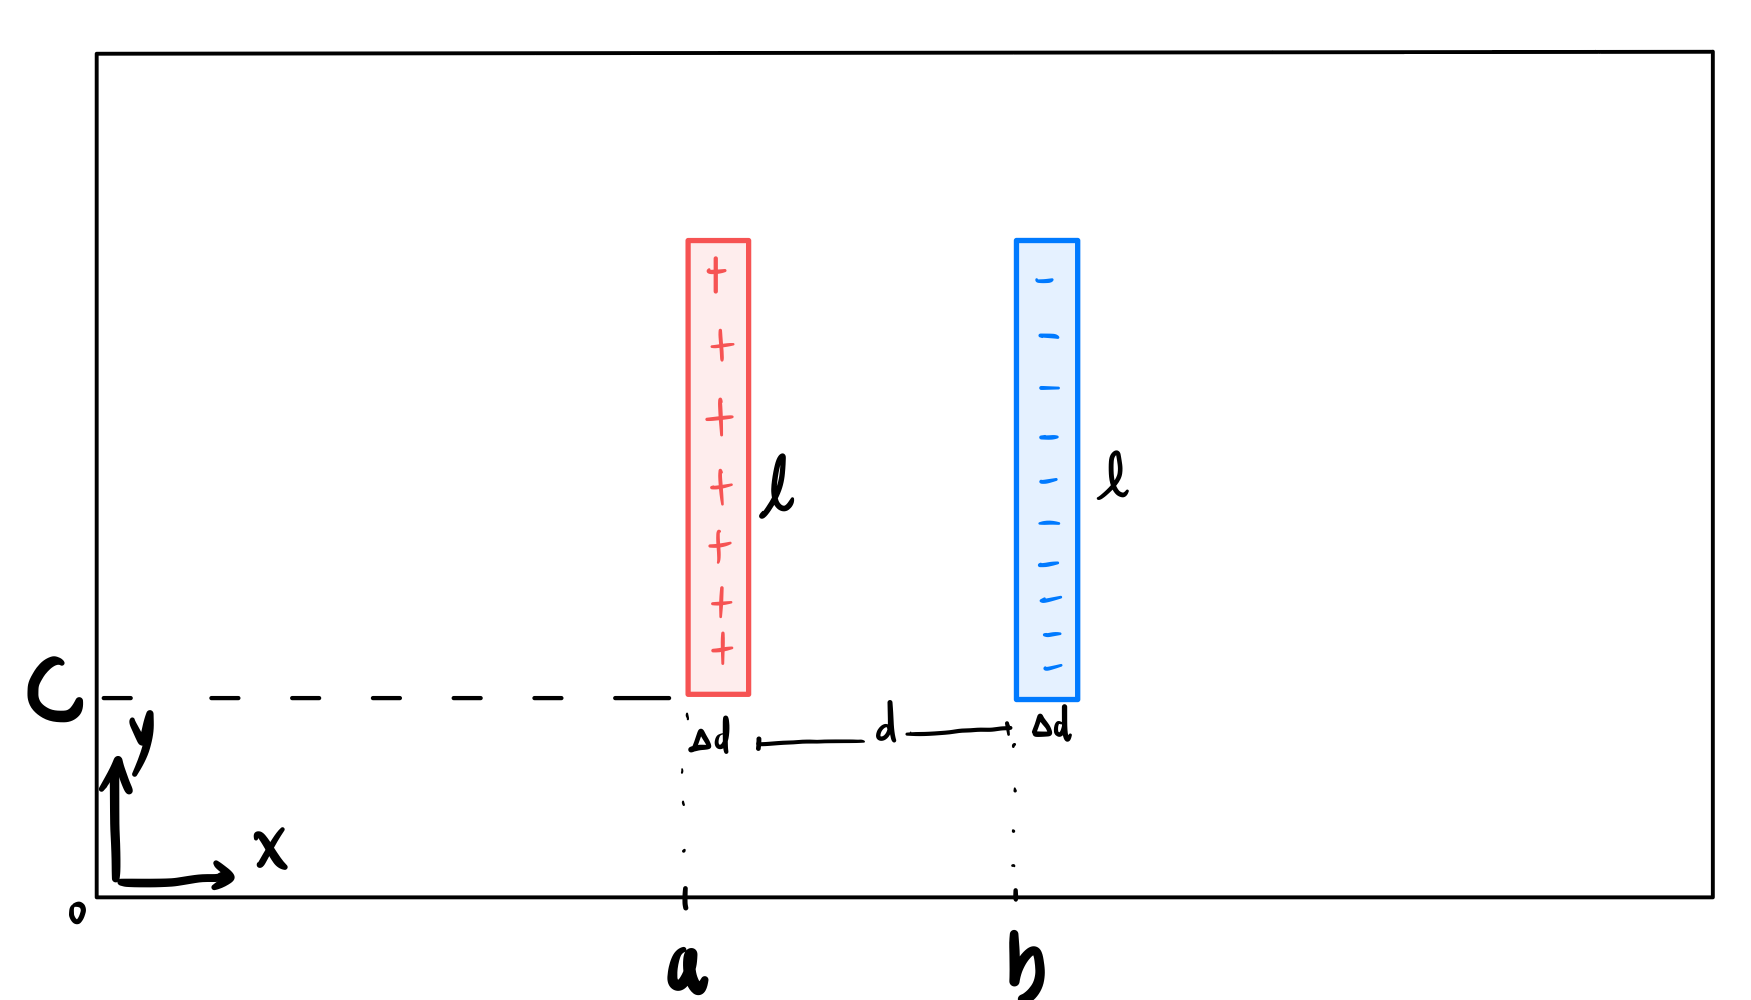

In [6]:
from IPython.display import Image
Image(filename=path+filename5, width=500)

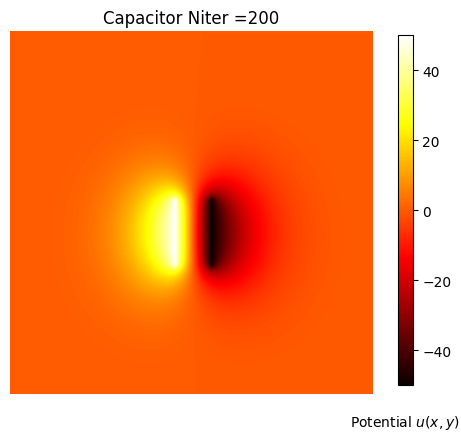

In [9]:
# let's construc you own rutine. As an example:
from capacitor import capacitor_df #my rutine

# Plot imshow
Niter = 200
V = capacitor_df(Niter)
fig, ax = plt.subplots(figsize=(5,5) )
im = ax.imshow(V.copy(),cmap="hot",interpolation="bilinear",)
ax.set_axis_off()
ax.set_title('Capacitor Niter =%.1d'%Niter)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("Potential $u(x,y)$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

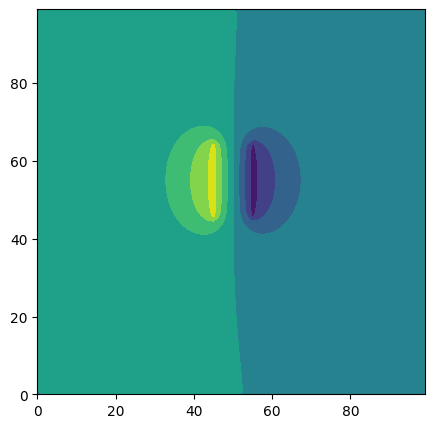

In [10]:
plt.subplots(figsize=(5,5) )
plt.contourf(V)
plt.show()

Es un problema curioso, interesante, se puede jugar bastante con él, porque tenemos varias fronteras qué considerar: los típicos extremos en el infinito (nosotros podemos suponer una caja lo suficientemente grande en la que se anulan los extremos) y las placas delgadas, que actúan como una frontera en sí misma, es una belleza de problema. 

Dado que las placas son delgadas podemos suponer que son del ancho de nuestro espacio a trabajar, llamémoslo $\Delta d$. Luego, ¿qué frontera le ponemos a las placas y cómo las programamos?
Por la libertad del ejercicio (bendita libertad) tiremos por lo fácil (que, aparentemente, es la solución mostrada por el profe), considerar las placas en un potencial constante, de modo que tengan una diferencia de potencial de 100 V. Dado buscamos que la solución mantenga cierta simetría (antisimetría si se piensa en el signo menos de los valores de potencial), y estamos fijando a 0 en los bordes, podemos considerar que, sobre los píxeles que representan las placas el potencial vale $-V_0/2$ y $V_0/2$, de modo que la diferencia de potencial entre las placas es, obviamente, $V_0$.

Considerando estas fronteras, lo único que cambia con los problemas anteriores es que debemos tener cuidado cuando recorremos la matriz que representa nuestro plano, ubicando de antemano las placas y considerándolas como fronteras (valores fijos). Vamos allá


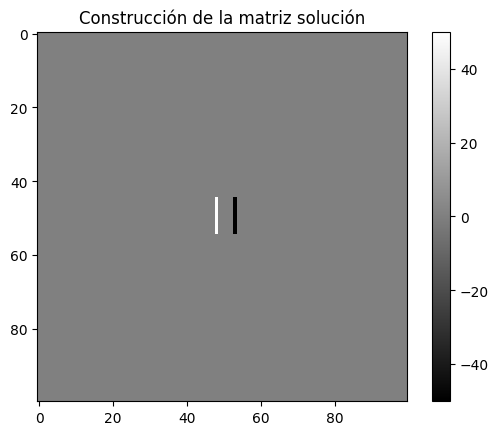

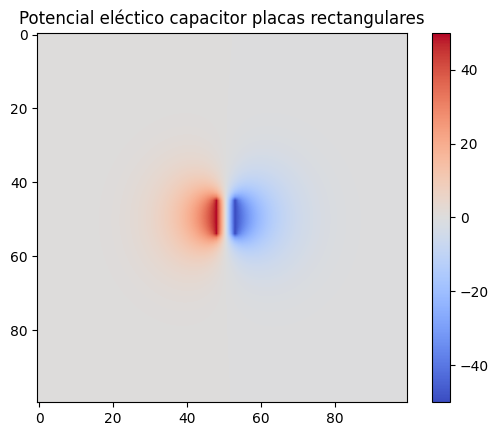

In [39]:
# Vamos a dividir nuestro espacio sin escalas, es decir, los deltas son iguales en ambas variables, de modo que no fregamos con eso
# Definamos primero nuestro plano y lo concerniente a las placas (posiciones y longitudes), sin preocuparnos por dimensiones físicas,
# vamos a pensarlo en píxeles y cuadrado, pa hacerlo más fácil todavía (qué perezoso, podría pensar el lector, pero es lo permitido en la libertad):
# Primero el plano
import numpy as np
import matplotlib.pyplot as plt
n = 100 # Dejémoslo como una variable por si nos da la gana de jugar con esto.
x = np.arange(0,100)
X,Y = np.meshgrid(x,x) # No las vamos a usar, pero es bueno tenerlas a la mano (la costumbre)
# La longitud de las placas que sea de la quiero que sean de una décima parte del tamaño del plano (pensado en píxeles)
# Esta longitud es bastante, si quisieramos una mejor aproximación tendría que ser más pequeño (es en el infinito que las bordes se anulan),
# pero para no matar la computadora, supongamos que ya con eso podemos asumir condiciones de infinito en los bordes de nuestro plano.
l = n//10
# Luego hay que ubicar las placas, para que estén juntitas, que sea de la mitad de l, porque quiero
d = l//2
# Por supuesto, lo concerniente a las placas es totalmente arbitrario, se puede jugar con todo esto, por eso dejo las variables declaradas
# y no trabajo con valores impuestos.
# Para la posición de las placas es sencillo, me paro en la mitad del plano y echo pa'trás la mitad de d, ubico una placa y echo pa'lante la mitad de d.
# hasta ahí está bien, pero, haciendo las cuentas a la ligera, voy a cometer un error si d es impar... echo pa'trás la mitad de d y a partir de ahí, echo pa'lante. (guiño)
positiva = n//2-d//2
negativa = positiva+d
# Por último, la diferencia de potencial
V_0 = 100
# Eso es todo, ahora vamos a definir la matriz que contiene el potencial
u = np.zeros((n,n))
# Esta tiene la ventaja de que los bordes ya son 0
# Ahora hay que ubicar las placas, por supuesto, en el medio del plano
# El positivo
u[n//2-l//2: n//2-l//2+l,positiva] = V_0//2
u[n//2-l//2: n//2-l//2+l,negativa] =  V_0//2-V_0

# Quiero mostrar la matriz antes de pasar al quid del asunto (la iteración correcta sobre la solución manteniendo la frontera)
plt.imshow(u, cmap='gray')
plt.title('Construcción de la matriz solución')
plt.colorbar()
plt.show()

# Ahora sí, tres cucharadas de sopa y mano a la presa
# Iteremos lo mismo que el profe, 200 veces
iter = 500
for k in range(200):
    for i in range(1,n-1):
        for j in range(1, n-1):
            if (i not in range(n//2-l//2, n//2-l//2+l) or ((j !=positiva) and (j!=negativa))): # lo interesante del ejercicio es reocorrer correctamente la
                u[i,j] = 1/4 * (u[i-1,j]+u[i+1,j]+u[i,j-1]+u[i,j+1])

plt.imshow(u, cmap="coolwarm",interpolation="bilinear") # Se hace interpolación para que se vea más bonito
plt.title('Potencial eléctico capacitor placas rectangulares')
plt.colorbar()
plt.show()




Ahora, para el campo eléctrico queremos el gradiente de phi. Podemos tirar derivada pa'lante y pa'trás:

\begin{equation}
 \phi(x+\Delta x,y) \approx \phi(x,y) + \frac{\partial \phi}{\partial x} \Delta x \biggm|_{x,y} \text{  pa´lante}\,,
\end{equation}

\begin{equation}
\phi(x-\Delta x,y) \approx \phi(x,y) - \frac{\partial \phi}{\partial x} \Delta x \biggm|_{x,y} \text{   pa'trás},
\end{equation}


Restando y dividiendo:

\begin{equation}
 \frac{\partial \phi}{\partial x} \approx \frac{\phi(x+\Delta x,y)-\phi(x-\Delta x,y)}{2\Delta x}
\end{equation}

De manera análoga para $y$ (esto ya lo hicimos en métodos, ¿por qué hay que repetir temario, si ya los vimos? ¿cuál es la necesidad?).
Asumiendo que 
\begin{equation}
 \textbf{E} = -\nabla \phi,
\end{equation}
Si programamos esa derivada, hemos resuelto nuestro problema



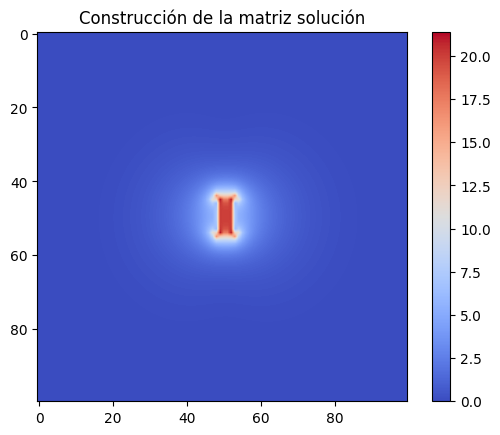

In [40]:
# Nuevamente por la libertad del ejercicio podemos asumir que delta x y delta y son 1, nos movemos a pasos de unidad (¿la libertad nos vuelve perezosos?).
# Así, construyamos el gradiente, no hay que iterar, ni nada, solo calcular.
Ex = np.zeros_like(u)
Ey = np.zeros_like(u)

for i in range(1, n-1):
    for j in range(1, n-1):
        Ex[i,j] = -(u[i+1,j] - u[i-1,j]) / 2
        Ey[i,j] = -(u[i,j+1] - u[i,j-1]) / 2
# Estas vendrían a ser las dos componentes del campo eléctrico, podríamos observar su módulo

plt.imshow(np.sqrt(Ex**2+Ey**2), cmap="coolwarm",interpolation="bilinear") # Se hace interpolación para que se vea más bonito
plt.title('Construcción de la matriz solución')
plt.colorbar()
plt.show()
# Se ve casi uniforme dentro y fuera del capacitor y se observan los efectos de borde. Neat!!! 

NOTA: Muy bien. Se nota manejo en la contracción del potencial. El campo electrico no se visualiza bien. Es un campo vectorial... nota 4.5... mejorarlo...

porquÉ ES es CaMACHO_0909 .... 3909

# Streamlines, colored by field magnitude
magnitude = np.sqrt(Ex**2 + Ey**2)
ax.streamplot(X, Y, Ex, Ey,
                color = magnitude, cmap = 'inferno',
                density=1.5, linewidth=0.5)

In [ ]:
otra opcion es np.quiver